In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [2]:
movies = pd.read_csv("movies.csv")
ratings = pd.read_csv("ratings.csv")

movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [3]:
movies.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9742 entries, 0 to 9741
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   movieId  9742 non-null   int64 
 1   title    9742 non-null   object
 2   genres   9742 non-null   object
dtypes: int64(1), object(2)
memory usage: 228.5+ KB


In [4]:
movies.shape

(9742, 3)

In [5]:
ratings.shape

(100836, 4)

In [6]:
movies.isnull().sum()

movieId    0
title      0
genres     0
dtype: int64

In [7]:
ratings.isnull().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [8]:
movies.head(10)


,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


In [9]:
ratings.head(10)

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [10]:
movies['genres'].value_counts().head(10)

genres
Drama                   1053
Comedy                   946
Comedy|Drama             435
Comedy|Romance           363
Drama|Romance            349
Documentary              339
Comedy|Drama|Romance     276
Drama|Thriller           168
Horror                   167
Horror|Thriller          135
Name: count, dtype: int64

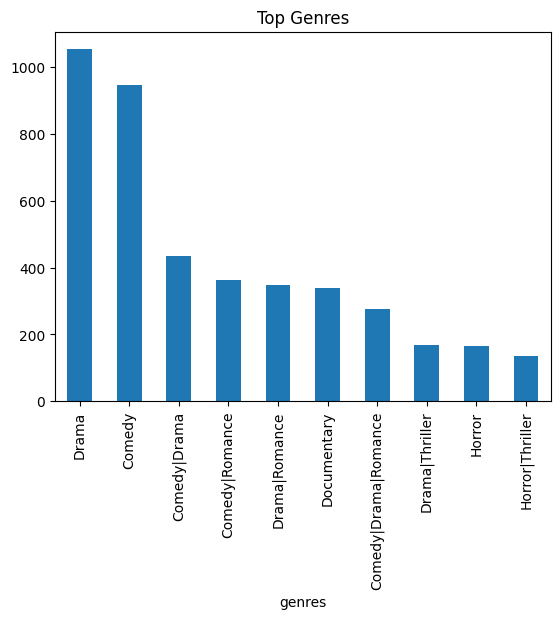

In [11]:
movies['genres'].value_counts().head(10).plot(kind='bar')
plt.title("Top Genres")
plt.show()

In [12]:
movies.drop_duplicates(inplace=True)
ratings.drop_duplicates(inplace=True)

In [13]:
movies.shape

(9742, 3)

In [14]:
cv = CountVectorizer()

vectors = cv.fit_transform(movies['genres']).toarray()

vectors.shape

(9742, 24)

In [15]:
similarity = cosine_similarity(vectors)

similarity.shape

(9742, 9742)

In [16]:
def recommend(movie):
    
    movie_index = movies[movies['title'] == movie].index[0]

    distances = similarity[movie_index]

    movie_list = sorted(
        list(enumerate(distances)),
        reverse=True,
        key=lambda x: x[1]
    )[1:6]

    print("Recommended Movies:\n")

    for i in movie_list:
        print(movies.iloc[i[0]].title)

In [17]:
recommend("Toy Story (1995)")

Recommended Movies:

Antz (1998)
Toy Story 2 (1999)
Adventures of Rocky and Bullwinkle, The (2000)
Emperor's New Groove, The (2000)
Monsters, Inc. (2001)


In [18]:
recommend("Jumanji (1995)")

Recommended Movies:

Indian in the Cupboard, The (1995)
NeverEnding Story III, The (1994)
Escape to Witch Mountain (1975)
Darby O'Gill and the Little People (1959)
Return to Oz (1985)


In [19]:
recommend("Batman Forever (1995)")

Recommended Movies:

Batman Forever (1995)
It's a Mad, Mad, Mad, Mad World (1963)
I Spy (2002)
Nothing to Lose (1997)
Crime Busters (1977)
